<a href="https://colab.research.google.com/github/MarcusMikael/SimulacaodeMonteCarlo-CasoTechToy/blob/main/Simula%C3%A7%C3%A3o_de_Monte_Carlo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Simulação de Monte Carlo - Caso TechToy**
1. **Introdução e Contexto**

A empresa TechToy está prestes a lançar um novo drone no mercado. A diretoria está em dúvida entre duas estratégias de lançamento e contratou você, analista de dados, para realizar uma Simulação de Monte Carlo.

O objetivo é entender não apenas o lucro esperado, mas o risco de prejuízo de cada decisão.

As Estratégias:
Estratégia A (Conservadora): Foca em um público de nicho, com preço mais alto e vendas mais previsíveis.

Estratégia B (Agressiva): Foca em escala, com preço menor, mas com custos de produção e volume de vendas muito mais incertos.

**2. Base de Dados e Parâmetros**

Execute a célula abaixo para carregar as bibliotecas necessárias e os parâmetros oficiais fornecidos pelo departamento financeiro.

In [66]:
import numpy as np
import matplotlib.pyplot as plt

# Configurações da Simulação
N_SIMULACOES = 10000

# --- PARÂMETROS ESTRATÉGIA A ---
vendas_media_a = 500
vendas_desvio_a = 50
custo_min_a = 600
custo_max_a = 700
preco_venda_a = 1200
investimento_fixo_a = 50000

# --- PARÂMETROS ESTRATÉGIA B ---
vendas_media_b = 800
vendas_desvio_b = 250
custo_min_b = 400
custo_max_b = 800
preco_venda_b = 1000
investimento_fixo_b = 150000

print("Parâmetros carregados com sucesso!")

Parâmetros carregados com sucesso!


3. Desafio

**1: Modelagem do Lucro**

Crie uma função ou um script que utilize os parâmetros acima para gerar 10.000 resultados possíveis de lucro para cada estratégia.Dicas:Para as Vendas, use uma distribuição Normal: np.random.normal(media, desvio, N_SIMULACOES).Para o Custo Unitário, use uma distribuição Uniforme: np.random.uniform(min, max, N_SIMULACOES).

A fórmula do lucro é:

$Lucro = (Vendas \times Preço) - (Vendas \times Custo\_Unitário) - Investimento\_Fixo$

Lucro Médio: R$ 225210.54
Pessimista (P5): R$ 175301.67
Otimista (P95): R$ 276858.42


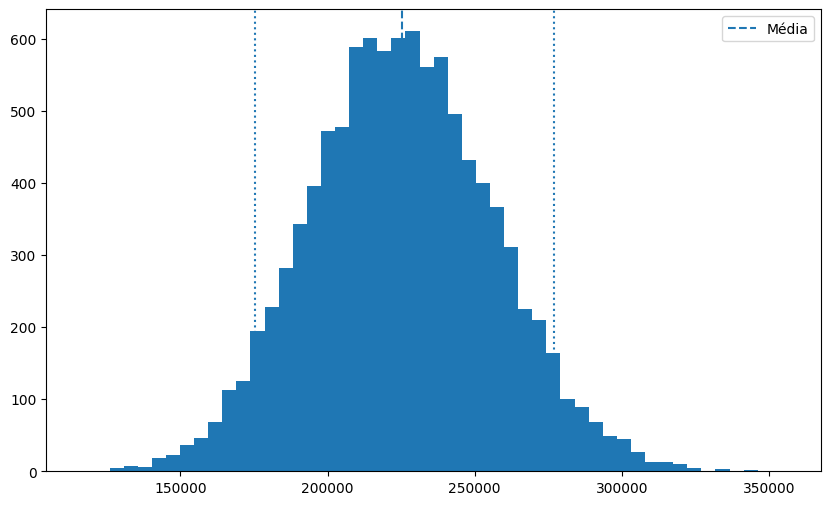

In [67]:
# Parâmetros A
vendas = np.random.normal(500, 50, N_SIMULACOES)
custo_unitario_a = np.random.uniform(600, 700, N_SIMULACOES)
preco_venda_a = 1200
investimento_fixo_a = 50000

# Cálculo do lucro
lucro_a = (vendas * preco_venda_a) - (vendas * custo_unitario_a) - investimento_fixo_a

# Análise
media_lucro_a = np.mean(lucro_a)
p5 = np.percentile(lucro_a, 5)
p95 = np.percentile(lucro_a, 95)

print(f"Lucro Médio: R$ {media_lucro_a:.2f}")
print(f"Pessimista (P5): R$ {p5:.2f}")
print(f"Otimista (P95): R$ {p95:.2f}")

# Gráfico
plt.figure(figsize=(10, 6))
plt.hist(lucro_a, bins=50)
plt.axvline(media_lucro_a, linestyle='--', label='Média')
plt.axvline(p5, linestyle=':')
plt.axvline(p95, linestyle=':')
plt.legend()
plt.show()

Lucro Médio: R$ 169048.14
Pessimista (P5): R$ -22133.08
Otimista (P95): R$ 423024.12


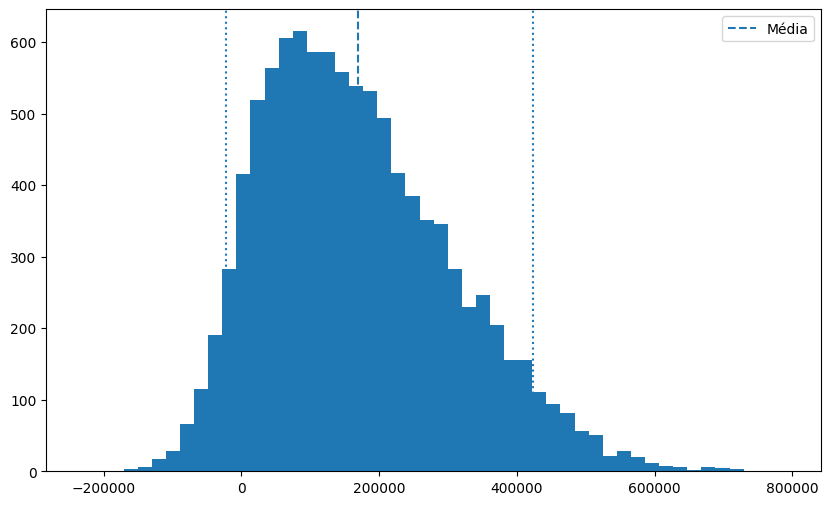

In [68]:
# Parametros B
vendas = np.random.normal(800, 250, N_SIMULACOES)
custo_unitario_b = np.random.uniform(400, 800, N_SIMULACOES)
preco_venda_b = 1000
investimento_fixo_b = 150000

# Cálculo do lucro
lucro_b = (vendas * preco_venda_b) - (vendas * custo_unitario_b) - investimento_fixo_b

# Análise
media_lucro_b = np.mean(lucro_b)
p5 = np.percentile(lucro_b, 5)
p95 = np.percentile(lucro_b, 95)

print(f"Lucro Médio: R$ {media_lucro_b:.2f}")
print(f"Pessimista (P5): R$ {p5:.2f}")
print(f"Otimista (P95): R$ {p95:.2f}")

# Gráfico
plt.figure(figsize=(10, 6))
plt.hist(lucro_b, bins=50)
plt.axvline(media_lucro_b, linestyle='--', label='Média')
plt.axvline(p5, linestyle=':')
plt.axvline(p95, linestyle=':')
plt.legend()
plt.show()

**2: Visualização dos Resultados**

Gere um histograma comparando as duas estratégias. O gráfico deve ajudar a diretoria a visualizar onde o lucro se concentra e onde estão os riscos de perda (valores abaixo de zero).

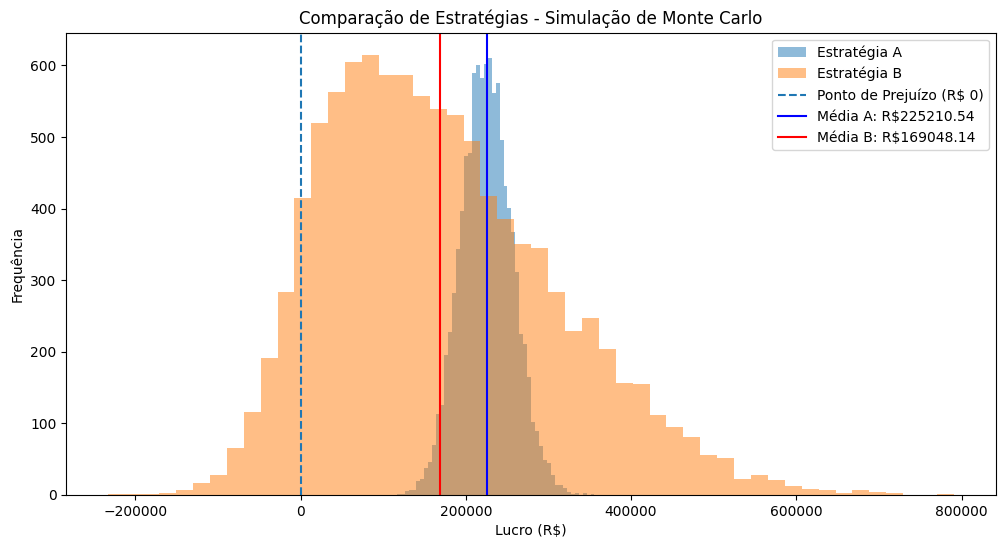

In [69]:
plt.figure(figsize=(12, 6))

# Histograma A
plt.hist(lucro_a, bins=50, alpha=0.5, label='Estratégia A')

# Histograma B
plt.hist(lucro_b, bins=50, alpha=0.5, label='Estratégia B')

# prejuízo
plt.axvline(0, linestyle='--', label='Ponto de Prejuízo (R$ 0)')

# Médias
plt.axvline(np.mean(lucro_a),color='blue', linestyle='-', label=f'Média A: R${media_lucro_a:.2f}')
plt.axvline(np.mean(lucro_b),color='red', linestyle='-', label=f'Média B: R${media_lucro_b:.2f}')

plt.title('Comparação de Estratégias - Simulação de Monte Carlo')
plt.xlabel('Lucro (R$)')
plt.ylabel('Frequência')
plt.legend()

plt.show()

**3: Cálculo de Probabilidades**
Calcule e exiba as seguintes métricas para cada estratégia:

Média de Lucro.

Probabilidade de Prejuízo (porcentagem de simulações onde o lucro foi < 0).

In [70]:
# ESTRATÉGIA A
media_lucro_a = np.mean(lucro_a)
prob_prejuizo_a = np.mean(lucro_a < 0) * 100 # Se o lucro for menor que 0, vai ser considerado como prejuízo.

# ESTRATÉGIA B
media_lucro_b = np.mean(lucro_b)
prob_prejuizo_b = np.mean(lucro_b < 0)

print("Estratégia A:")
print(f"Lucro Médio: R$ {media_lucro_a:.2f}")
print(f"Probabilidade de Prejuízo: {prob_prejuizo_a:.2f}%\n")

print("Estratégia B:")
print(f"Lucro Médio: R$ {media_lucro_b:.2f}")
print(f"Probabilidade de Prejuízo: {prob_prejuizo_b:.2f}%")


Estratégia A:
Lucro Médio: R$ 225210.54
Probabilidade de Prejuízo: 0.00%

Estratégia B:
Lucro Médio: R$ 169048.14
Probabilidade de Prejuízo: 0.08%


A Estratégia A apresenta um lucro médio maior  e probabilidade de prejuízo nula, indicando uma constância e baixo risco. Com isso demonstrando que seus resultados são mais previsíveis e consistentes ao longo das simulações.

Já a Estratégia B possui um lucro médio menor e uma pequena probabilidade de prejuízo, o que indica uma variância maior nos resultados. Com possibilidade de ganhos elevados em algumas simulações, porém há risco de perdas.

Dessa forma, a Estratégia A se mostra mais segura, pois combina maior retorno médio com menor risco, sendo a opção mais indicada para a empresa.